In [258]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, mannwhitneyu, chi2_contingency
from scipy.stats import fisher_exact
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import t

df = pd.read_csv("data.csv", sep=';')

## Гипотеза 4. У студентов вечернего отделения динамика успеваемости (изменение от 1-го ко 2-му семестру) лучше, чем у дневных


**Формулировка гипотезы**:

Среднее изменение успеваемости (разность между средними оценками 1 и 2 семестра) у студентов вечернего отделения статистически значимо выше, чем у студентов дневного отделения.

Переменные

Группирующий фактор: is_evening_attendance (1 – вечернее, 0 – дневное).

Непрерывная переменная: grade_gap (может быть отрицательной, нулевой, положительной).

### Создадим нужные признаки

За форму обучения отвечает признак `Daytime/evening attendance` (1 – daytime 0 - evening), для удобства заменим его на `is_evening_attendance`, где наоборот 1 будет означать вечернее обучение

In [259]:
df['is_evening_attendance'] = (df['Daytime/evening attendance\t'] == 0).astype(int)

Также не хватает признака с разницей между оценками 1 и 2 семестра

In [260]:
df['grade_gap'] = df['Curricular units 2nd sem (grade)'] - df['Curricular units 1st sem (grade)']

И еще сделаем признаки с абсолютным значением изменения оценки и трендом на улучшение или ухудшение оценки (1 - улучшение успеваемости, 0 - ухудшение)

In [261]:
df['grade_gap_abs'] = np.abs(df['grade_gap'])

In [262]:
df['trend'] = (df['grade_gap'] > 0).astype(int)

Разделим по группам

In [263]:
gap_evening = df[df['is_evening_attendance'] == 1]['grade_gap']
gap_day = df[df['is_evening_attendance'] == 0]['grade_gap']

In [264]:
evening = df[df['is_evening_attendance'] == 1]
day = df[df['is_evening_attendance'] == 0]

И финально преобразуем целевую переменную в бинарную, чтобы можно было посмотреть именно на факт отчисления:

- 1 - студент отчислился (Dropout)
- 0 - не отчислился (Enrolled и Graduate)

In [265]:
df['is_dropout'] = (df['Target'] == 'Dropout').astype(int)

### Кто обучается на вечернем отделении

In [266]:
df['is_evening_attendance'].value_counts()

,count
is_evening_attendance,
0,3941
1,483


Студентов на вечернем намного меньше, всего 12%

Для начала в целом интересно посмотреть на портрет человека, обучающегося на вечером

/tmp/ipykernel_2186/1584926619.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Дневное', 'Вечернее'])


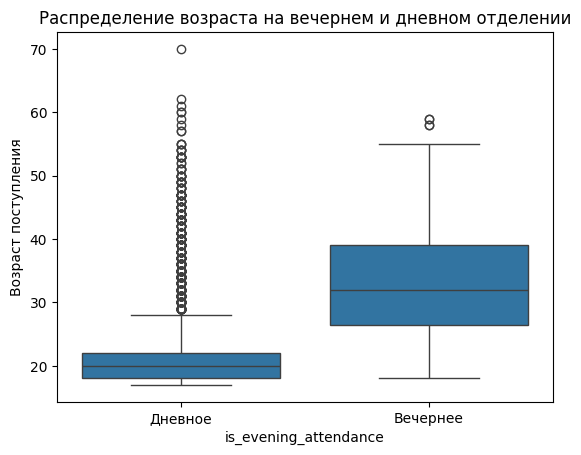

In [267]:
ax = sns.boxplot(x='is_evening_attendance', y='Age at enrollment', data=df)
ax.set_title('Распределение возраста на вечернем и дневном отделении')
ax.set_xticklabels(['Дневное', 'Вечернее'])
ax.set_ylabel('Возраст поступления')
plt.show()

In [268]:
df.groupby('is_evening_attendance')['Age at enrollment'].median()

,Age at enrollment
is_evening_attendance,
0,20.0
1,32.0


Вполне закономерно, что медианный возраст студентов за вечернем намного выше дневного и состовляет 32 года

/tmp/ipykernel_2186/3054055579.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Дневное', 'Вечернее'])
/tmp/ipykernel_2186/3054055579.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Дневное', 'Вечернее'])


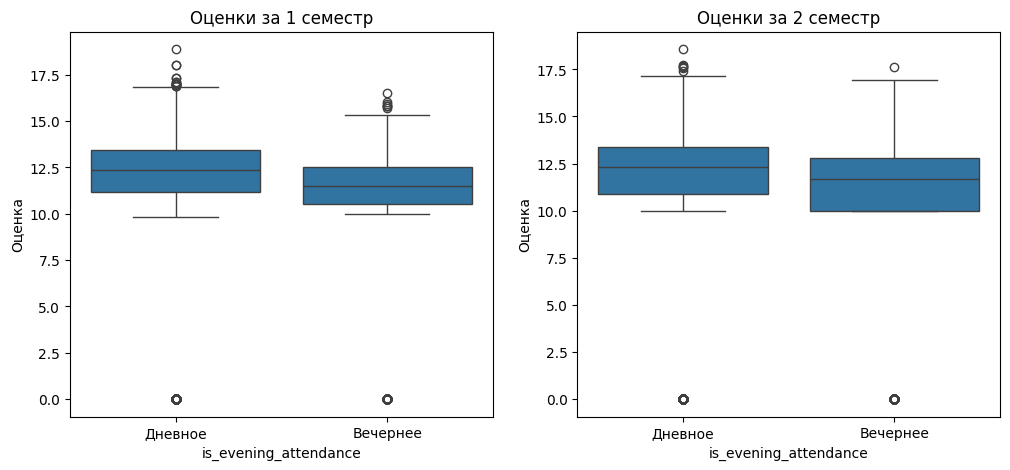

In [269]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='is_evening_attendance', y='Curricular units 1st sem (grade)', data=df, ax=axes[0])
axes[0].set_xticklabels(['Дневное', 'Вечернее'])
axes[0].set_title('Оценки за 1 семестр')
axes[0].set_ylabel('Оценка')

sns.boxplot(x='is_evening_attendance', y='Curricular units 2nd sem (grade)', data=df, ax=axes[1])
axes[1].set_xticklabels(['Дневное', 'Вечернее'])
axes[1].set_title('Оценки за 2 семестр')
axes[1].set_ylabel('Оценка')

plt.show()

In [270]:
df.groupby('is_evening_attendance')['Curricular units 1st sem (grade)'].median()

,Curricular units 1st sem (grade)
is_evening_attendance,
0,12.375
1,11.500


In [271]:
df.groupby('is_evening_attendance')['Curricular units 2nd sem (grade)'].median()

,Curricular units 2nd sem (grade)
is_evening_attendance,
0,12.300000
1,11.666667


Вечерние студенты демонстрируют более низкую медиану оценки, однако ко 2 семестру, неожиданно, сокращаю разницу с дневными студентами, увеличивая медиану, в то время как у дневных студентов она наоборот немного падает

In [272]:
pd.crosstab(df['is_evening_attendance'], df['Debtor'])

Debtor,0,1
is_evening_attendance,,
0,3490,451
1,431,52


Должников не так много, около 12 % среди вечерних студентов

In [273]:
pd.crosstab(df['is_evening_attendance'], df['is_dropout'])

is_dropout,0,1
is_evening_attendance,,
0,2727,1214
1,276,207


Большое количество студентов на вечерней форме обучения отчисляются, посмотрим в процентах

In [274]:
crosstab = pd.crosstab(df['is_evening_attendance'], df['is_dropout'])

crosstab['dropout_rate'] = crosstab[1] / (crosstab[0] + crosstab[1])
crosstab[['dropout_rate']].round(3) * 100

is_dropout,dropout_rate
is_evening_attendance,
0,30.8
1,42.9


Если среди дневных студентов меньше трети отчисляется, то для вечерных студентов эта цифра близка к 50%

In [275]:
crosstab_drop = pd.crosstab(df['is_evening_attendance'], df['is_dropout'])
chi2, p, dof, expected = chi2_contingency(crosstab_drop)

In [276]:
p

np.float64(1.1416199101077951e-07)

In [277]:
p

np.float64(1.1416199101077951e-07)

In [278]:
dof

1

In [279]:
expected

array([[2675.14082278, 1265.85917722],
       [ 327.85917722,  155.14082278]])

Быстренько проведем хи-квадрат тест независимости, который проверит, связаны ли два форма обучения (дневная / вечерняя) и статус отчисления

H_0

Доля отчисленных не зависит от формы обучения – т.е. отчисляемость одинакова среди дневных и вечерних студентов.

Альтернативная гипотеза H_1

Доля отчисленных различается между формами обучения (есть статистически значимая связь).

Результат теста показал p-value = 0.000001, что сильно меньше 0.05, значит отвергаем нулевую гипотезу. Связь между формой обучения и отчислением статистически значима.

Значит, уверенно делаем вывод, что вечерняя форма обучения связана с более высоким риском отчисления.




**Теперь сосредоточимся именно на оценках**

In [280]:
gap_day.describe()

,grade_gap
count,3941.000000
mean,-0.426983
std,2.896510
min,-16.142857
25%,-0.625000
50%,0.000000
75%,0.425000
max,16.000000


In [281]:
gap_evening.describe()

,grade_gap
count,483.000000
mean,-0.277070
std,2.839256
min,-13.250000
25%,-0.447222
50%,0.000000
75%,0.612500
max,12.500000


Оказывается, стандартное отклонение у вечерних совсем немного меньше (2.839 и 2.897), а не больше, как нам казалось, а максимальный и минимальный разброс значений, также как и средняя разница, между семестрами также меньше

In [282]:
df.groupby('is_evening_attendance')[['grade_gap', 'grade_gap_abs']].mean()

,grade_gap,grade_gap_abs
is_evening_attendance,,
0,-0.426983,1.258973
1,-0.277070,1.272370


Вечерние студенты показывают меньшее среднее убывание оценок между семестрами, но в целом разница не такая большая

In [283]:
df.groupby('is_evening_attendance')['trend'].mean()

,trend
is_evening_attendance,
0,0.344836
1,0.403727


Общий тренд таков, что студенты на вечернем на самом деле сильнее улучшаю оценки за 2 семестр, чем дневные, даже не смотря на то, что рейтинг отчислений у них значительно выше.

Получается, что среди вечерних студентов около 40% улучшили успеваемость по сравнению с 1 семестром, и при этом 42% отчислены. Это может означать, что отсев среди вечерников истребляет самых слабых, а оставшиеся более мотивированы и адаптируются.



In [284]:
pd.crosstab(df['trend'], df['is_dropout'])

is_dropout,0,1
trend,,
0,1758,1112
1,1245,309


In [285]:
dropout_rate_by_trend = df.groupby('trend')['is_dropout'].mean()
dropout_rate_by_trend.round(3) * 100

,is_dropout
trend,
0,38.7
1,19.9


улучшение успеваемости ассоциировано с двукратным снижением риска отчисления

In [286]:
crosstab = pd.crosstab(df['trend'], df['is_dropout'], normalize='columns')

crosstab.loc[1,1]*100

np.float64(21.745249824067557)

основная масса отчислений приходится на студентов без положительной динамики, но примерно каждый пятый отчисленный учился лучше во втором семестре, что указывает на то, что одного улучшения недостаточно для гарантии успешного завершения обучения

Перейдем наконец к статистическим тестам

**Сначала посмотрим, есть ли статистическая значимость у разницы средних значений изменения оценок от 1 семестра ко 2 у вечернего и дневного отделения**

### Выбор статистического теста - Независимый двухвыборочный t-тест (односторонний)


Так как цель - сравнение средних двух независимых групп, t-тест является стандартным и общепринятым методом.

grade_gap непрерывная переменная

Объём выборки у нас достаточно большой (4424),благодаря центральной предельной теореме (ЦПТ), распределение выборочного среднего приближается к нормальному при достаточно большом объёме выборки

В группе дневных: n = 3941 - очень большое, ЦПТ работает

В группе вечерних: n = 483 что тоже достаточно велико (n > 30 выполнено)

Мы используем одностороннюю альтернативу, так как ожидаем, что у вечерних падение оценок меньше





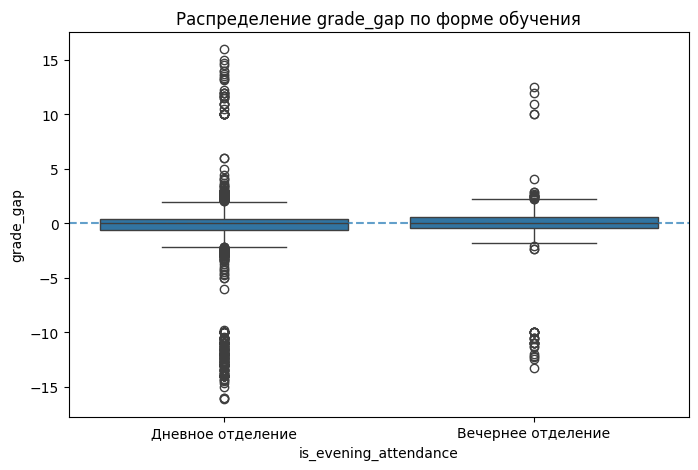

In [316]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='is_evening_attendance', y='grade_gap', data=df)
plt.xticks([0, 1], ['Дневное отделение', 'Вечернее отделение'])
plt.title('Распределение grade_gap по форме обучения')
plt.ylabel('grade_gap')
plt.axhline(y=0, linestyle='--', alpha=0.7)
plt.show()

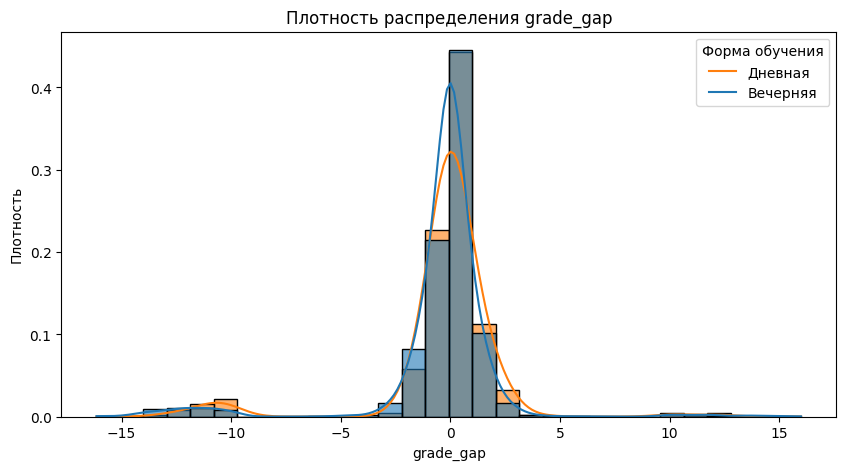

In [328]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='grade_gap', hue='is_evening_attendance', kde=True, stat='density', common_norm=False, bins=30, alpha=0.6)
plt.title('Плотность распределения grade_gap')
plt.xlabel('grade_gap')
plt.ylabel('Плотность')
plt.legend(title='Форма обучения', labels=['Дневная', 'Вечерняя'])
plt.show()

### Проверка условий применимости

1) Независимость наблюдений выполняется - разные студенты

2) Нормальность распределения формально не требуется при больших выборках, даже если исходное распределение `grade_gap` далеко от нормального, выборочное среднее будет близко к нормальному благодаря размеру выборок.

3) дисперсии практически равны


In [287]:
np.var(gap_evening)

8.044686176615732

In [288]:
np.var(gap_day)

8.387639695801662

### Формулировка статистических гипотез

Пусть:

Mu_day - среднее `grade_gap` для дневной формы обучения (те разницы оценок за 1 и 2 семестр)

Mu_evening - среднее `grade_gap` для вечерней формы обучения

H_0:

**Mu_day = Mu_evening**

H_1 (альтернативная):

**Mu_day < Mu_evening**

In [289]:
t_stat, p_t = ttest_ind(gap_evening, gap_day, alternative='greater', equal_var=False)

In [290]:
t_stat

np.float64(1.092796483703321)

In [291]:
p_t

np.float64(0.1374567154713024)

Не можем опровергнуть нулевую гипотезу о равенстве средних `grade_gap` (дневные и  вечерние). Разница в динамике средних оценок за семестры между формами обучения статистически не значима на уровне 0.05.

Посмотрим на доверительный интервал разности средних (95%), расчитаем число степеней свободы по формуле Саттертвейта

In [292]:
s1_sq = np.var(gap_evening, ddof=1)
s2_sq = np.var(gap_day, ddof=1)
n1 = len(gap_evening)
n2 = len(gap_day)
diff = gap_evening.mean() - gap_day.mean()

se_diff = np.sqrt(s1_sq/n1 + s2_sq/n2)

df1 = (s1_sq/n1 + s2_sq/n2)**2 / ( (s1_sq/n1)**2/(n1-1) + (s2_sq/n2)**2/(n2-1) )


t_crit = t.ppf(0.975, df1)
ci_lower = diff - t_crit * se_diff
ci_upper = diff + t_crit * se_diff

Разность средних

In [293]:
diff

np.float64(0.1499126513667733)

Стандартная ошибка

In [294]:
se_diff

np.float64(0.13718258944130388)

Степени свободы, достаточно большое число, поэтому t-распределение близко к нормальному

In [295]:
df1

611.5829623808974

95% ДИ для разности включает ноль, что означает, что на уровне доверия 95% мы не можем исключить возможность того, что истинная разность средних равна нулю



In [296]:
f"[{ci_lower:.4f}, {ci_upper:.4f}]"

'[-0.1195, 0.4193]'

In [297]:
pooled_sd = np.sqrt((s1_sq + s2_sq)/2)
cohens_d = diff / pooled_sd

In [298]:
cohens_d

np.float64(0.05227032720885549)

### Итоговый вывод по t-тесту

T-тест не выявил статистически значимых различий в среднем `grade_gap` между дневными и вечерними студентами:

Разность средних = 0.15 (вечерние показывают чуть меньшее падение).

95% доверительный интервал разности включает ноль: [-0.12, 0.42].

Cohen's d = 0.05 - эффект практически отсутствует.

Таким образом, нулевая гипотеза о равенстве средних не отвергается.

### U-тест Манна–Уитни
https://thecode.media/kak-rabotaet-u-kriteriy-manna-uitni/


U-критерий Манна - Уитни - непараметрический статистический тест, используемый для сравнения двух независимых выборок по уровню какого-либо количественного признака.

Он позволяет выявить статистически значимые различия между группами, даже если данные не подчиняются нормальному распределению или имеют выбросы



###Условия применимости

1) выборки независимые

2) `grade_gap` является интервальной переменной, её можно ранжировать

3) В каждой выборке больше 3 наблюдений

4) Есть также условие на то, что в выборочных данных не должно быть совпадающих значений или таких совпадений должно быть очень мало (до 10), но в современных реализациях (например, scipy.stats.mannwhitneyu который мы использовали) автоматически применяют поправку на связи и нормальное приближение, что делает тест корректным



### Гипотеза

U-тест проверяет гипотезу: Случайно выбранное значение из вечерней группы с вероятностью > 0.5 превышает значение из дневной группы (что называют стохастическое доминирование)

H_0:

Вероятность того, что случайно выбранное значение grade_gap из вечерней группы превышает значение из дневной группы, равна 0.5 (распределения одинаковы).

H_1:

Вероятность > 0.5 (вечерние склонны к более высоким grade_gap)

In [299]:
u_stat, p_u = mannwhitneyu(gap_evening, gap_day, alternative='greater')

In [300]:
u_stat

np.float64(1020602.0)

Это количество пар вечерний - дневной, где значение `grade_gap` у вечернего студента оказалось больше, чем у дневного.

In [301]:
p_u

np.float64(0.004372884737106074)

### Вывод

Ранее t-тест дал p = 0,137, что не позволило орповергнуть гипотезу. U-тест более устойчивый к выбросам и ненормальности, показывает статистически значимое различие p < 0,01. Это означает, что t-тест потерял мощность из-за особенностей распределения (асимметрия, выбросы), а U-тест их учитывает корректно.

Нулевая гипотеза в данном тесте отвергается.
Вечерние студенты демонстрируют статистически значимо более высокие значения grade_gap по сравнению с дневными (p = 0,004). Падение успеваемости от первого ко второму семестру у вечерних меньше или чаще наблюдается улучшение, чем у дневных.


### Хи-квадрат тест независимости

Долее будем проводить тесты, чтобы посмотреть, есть ли статистическаи значимая связь между трендом улучшения успеваемости и формой обучения.

В этой гипотезе обе переменные являются категориальными:

`trend`: есть ли учучшение среднего балла между 1 и 2 семестром

`is_evening_attendance`: форма обучения

Для проверки независимости двух категориальных переменных нам как раз подходит хи-квадрат тест

Он проверит, отличаются ли наблюдаемые частоты в таблице сопряженности от тех частот, которые ожидались бы при независимости переменных

### Условия применимости

1) наши наблюдения независимы
2) переменные категориальны
3) ожидаемые частоты в ячейках таблицы сопряженности не слишком малы

### Гипотезы

H_0: Признаки `is_evening_attendance` и `trend` независимы

H_1: Признаки зависимы



In [302]:
pd.crosstab(df['is_evening_attendance'], df['trend'])

trend,0,1
is_evening_attendance,,
0,2582,1359
1,288,195


In [303]:
crosstab = pd.crosstab(df['is_evening_attendance'], df['trend'])

chi2, p_chi, dof, expected = chi2_contingency(crosstab)

In [304]:
chi2

np.float64(6.292357238198432)

In [305]:
p_chi

np.float64(0.012125967673876753)

In [309]:
p_chi < 0.05

np.True_

In [306]:
expected

array([[2556.66139241, 1384.33860759],
       [ 313.33860759,  169.66139241]])

Все ожидаемые частоты достаточно велики

p-value меньше уровня значимости 0.05, следовательно отвергаем нулевую гипотезу о независимости между трендом улучшения успеваемости и формой обучения, они статистически связаны

Сравним результат также с z-тестом для двух долей и тестом Фишера.


### z-тест

In [310]:
count = crosstab.loc[1, 1], crosstab.loc[0, 1]
nobs = crosstab.loc[1].sum(), crosstab.loc[0].sum()

z, p_z = proportions_ztest(count, nobs, alternative='larger')


In [311]:
z, p_z

(np.float64(2.5589522670264233), np.float64(0.005249407796650161))

In [308]:
oddsratio, p_fisher = fisher_exact(crosstab, alternative='greater')

Fisher's exact: p=0.00639


In [312]:
oddsratio, p_fisher

(np.float64(1.2864085111601669), np.float64(0.006385637239305677))

Все три теста (хи-квадрат, z-тест, тест Фишера) показали статистически значимую связь между формой обучения и улучшением успеваемости (p < 0.05 во всех случаях). Вечерние студенты улучшают успеваемость во втором семестре значимо чаще, чем дневные. Гипотеза о лучшей динамике у вечерних подтверждается на высоком уровне значимости

### Выводы

Сравнение t-теста и U-теста для гипотезы о различии `grade_gap` между дневными и вечерними студентами


| Характеристика | t-тест (Уэлча) | U-тест Манна–Уитни |
|----------------|----------------|---------------------|
| **Тип теста** | Параметрический | Непараметрический (ранговый) |
| **Проверяемая гипотеза** | Равенство **средних** `grade_gap` | Стохастическое доминирование (сдвиг распределения) |
| **Чувствительность к выбросам** | Высокая (выбросы искажают среднее) | Низкая |
| **Требования к распределению** | Приблизительная нормальность (ЦПТ) | Не требуется |
| **Статистика** | t = 1.093 | U = 1 020 602 |
| **p-value (односторонний)** | 0.137 | 0.004 |
| **Статистический вывод** | Не отвергаем H_0 (различия не значимы) | Отвергаем H_0 (различия значимы) |
| **Содержательный вывод** | Среднее изменение успеваемости не различается | Распределение `grade_gap` у вечерних сдвинуто в сторону более высоких значений |


**t-тест** чувствителен к выбросам и асимметрии (`grade_gap` имеет экстремальные значения от –16 до +16, много нулей). Из-за этого стандартная ошибка разности средних завышена, мощность теста снижена.

**U-тест** устойчив к выбросам и не требует нормальности. Он обнаруживает сдвиг распределения, вечерние студенты систематически показывают более высокие `grade_gap`, даже если средние различаются незначительно. По сути он доказал, что вероятность того, что случайный вечерний студент имеет лучшую динамику, чем случайный дневной, значимо выше 0.5

## Сравнение хи-квадрат теста, z-теста и теста Фишера  
**Гипотеза:** форма обучения (дневная/вечерняя) связана с улучшением успеваемости во втором семестре (`trend = 1`).

### Исходные данные

| Форма обучения | Не улучшили  | Улучшили  | Всего | Доля улучшивших |
|----------------|-----------------|--------------|-------|----------------|
| Дневная    | 2582            | 1359         | 3941  | 34.5%           |
| Вечерняя   | 288             | 195          | 483   | 40.4%           |

### Результаты тестов

| Характеристика | хи-квадрат тест  | z-тест для двух долей | тест Фишера |
|----------------|--------------------|------------------------|---------------------|
| **Тип теста** | Непараметрический | Параметрический  | Непараметрический  |
| **Проверяемая гипотеза** | Независимость признаков (двусторонняя) | односторонняя | односторонняя |
| **Статистика** | хи-квадрат = 6.292 | z = 2.559 | – |
| **p-value** | 0.01213 | 0.00525  | 0.00639 |
| **Статистический вывод** | Отвергаем H_0 (связь есть) | Отвергаем H_0 (доля вечерних выше) | Отвергаем H_0 (OR > 1) |
| **Отношение шансов (OR)** | – | – | **1.29** (вечерние улучшают чаще в 1.29 раза) |

Знавения p-value в тестах различаются

**хи-квадрат-тест** даёт двусторонний p-value. Для односторонней альтернативы его можно разделить на 2, что даст примерно 0.00606 и приблизит занчение к p-value z-теста и точного теста Фишера.

**z-тест** использует нормальное приближение, которое при больших выборках работает хорошо.

**тест Фишера** не полагается на асимптотику и является самым привычным для таблиц 2×2, особенно при малых ожидаемых частотах (хотя у нас они все > 5).

### Интерпретация для администрация университета

| № | Вывод | Рекомендация |
|---|-------|---------------|
| 1 | **Форма обучения статистически значимо связана <br>с улучшением успеваемости** (p_value < 0.05) | Не рассматривать вечернее обучение как заведомо неуспешное. Среди вечерников есть <br>достаточно много мотивированных студентов, способных улучшать свои оценки от семетра к семестру |
| 2 | **Вечерние студенты улучшают успеваемость чаще, <br>чем дневные** (40.4% и 34.5% соответственно, разница 5.9 п.п.). | Создать специальные адаптационные программы для вечерников, например, <br> гибкое расписание, онлайн-консультации. |
| 3 | **Шансы улучшить успеваемость у вечерних в 1.29 раза выше** <br>(OR = 1.29). | Это сильный аргумент в пользу инвестиций в поддержку вечерних студентов, <br>так как отдача в виде роста успеваемости будет выше, чем у дневных. |
| 4 | **Несмотря на лучшую динамику, отчисляемость вечерних выше <br>(42.9% против 30.8%).** | Проблема отсева вечерних студентов скорее всего связана не с академическими проблемами, <br> а с внешними факторами (работа, финансы). Нужны не только академические меры, <br> но и социально-финансовая поддержка. |

